In [ ]:
# INTRODUCTION Part A — Regression on California Housing

# The California Housing dataset has been used to evaluate linear and regularized linear models. The dataset has been split into 80% training and 20% testing subsets to ensure a fair estimate of model generalization.
# Linear Regression has been used as the baseline model while Ridge and Lasso regressions have been evaluated across a logarithmic sweep of regularization strengths (alpha).
# Test mean squared error (MSE) is used as the cost to compare model performance.
# The cost versus alpha plots for Ridge and Lasso are produced to visualize how regularization strength affects test error.

In [ ]:
# Standard imports have been performed to support data handling, modeling, and plotting.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, confusion_matrix, classification_report


# A fixed random seed has been set to ensure reproducible splits and model behavior across runs.
RND = 42


# Printing library versions provides transparency and reproducibility information for grading.
import sklearn
print('sklearn version:', sklearn.__version__)

sklearn version: 1.6.1


In [ ]:
# The California Housing dataset has been fetched using sklearn's helper function.
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target
feature_names_cal = cal.feature_names


# The dataset has been divided into 80% training and 20% test sets to evaluate generalization.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=RND)


# A brief dataset summary has been printed to document sample size and feature names.
print('Total samples:', X_cal.shape[0])
print('Training samples:', Xc_train.shape[0])
print('Test samples:', Xc_test.shape[0])
print('Feature names:', feature_names_cal)

Total samples: 20640
Training samples: 16512
Test samples: 4128
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
# StandardScaler has been used to normalize the input features because regularization methods
# (Ridge and Lasso) penalize coefficients and are sensitive to the scale of features.
scaler_cal = StandardScaler()
Xc_train_s = scaler_cal.fit_transform(Xc_train)
Xc_test_s = scaler_cal.transform(Xc_test)

In [ ]:
# A linear regression baseline has been trained on the scaled training data. The baseline
# establishes a reference test MSE against which regularized models can be compared.
lr = LinearRegression()
lr.fit(Xc_train_s, yc_train)
y_lr_pred = lr.predict(Xc_test_s)
mse_lr = mean_squared_error(yc_test, y_lr_pred)
print('Linear Regression test MSE:', mse_lr)

Linear Regression test MSE: 0.5558915986952442


In [ ]:
# A logarithmic range of alpha values has been generated using logspace because regularization
# strengths often need to be tested across several orders of magnitude.
alphas = np.logspace(-4, 4, 50)

ridge_mse = []
lasso_mse = []

# Training Ridge and Lasso models for each alpha value
for a in alphas:
    ridge = Ridge(alpha=a, random_state=RND, max_iter=10000)
    ridge.fit(Xc_train_s, yc_train)
    y_r = ridge.predict(Xc_test_s)
    ridge_mse.append(mean_squared_error(yc_test, y_r))

    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(Xc_train_s, yc_train)
    y_l = lasso.predict(Xc_test_s)
    lasso_mse.append(mean_squared_error(yc_test, y_l))

# Convert to numpy arrays
ridge_mse = np.array(ridge_mse)
lasso_mse = np.array(lasso_mse)

# Find best alphas
best_ridge_idx = np.argmin(ridge_mse)
best_lasso_idx = np.argmin(lasso_mse)

best_ridge_alpha = alphas[best_ridge_idx]
best_lasso_alpha = alphas[best_lasso_idx]

print("Best Ridge alpha:", best_ridge_alpha, "Test MSE:", ridge_mse[best_ridge_idx])
print("Best Lasso alpha:", best_lasso_alpha, "Test MSE:", lasso_mse[best_lasso_idx])


Best Ridge alpha: 232.99518105153672 Test MSE: 0.5522313863233629
Best Lasso alpha: 0.009102981779915217 Test MSE: 0.5483406873885018


In [ ]:
# A concise summary has been constructed to compare Linear, best-Ridge, and best-Lasso models on
# the test dataset. This table will be part of the submission to demonstrate final performance.
reg_summary = pd.DataFrame({
'Model': ['LinearRegression', 'Ridge (best alpha)', 'Lasso (best alpha)'],
'Alpha': [np.nan, best_ridge_alpha, best_lasso_alpha],
'Test_MSE': [mse_lr, ridge_mse[best_ridge_idx], lasso_mse[best_lasso_idx]]
})
reg_summary

,Model,Alpha,Test_MSE
0,LinearRegression,NaN,0.555892
1,Ridge (best alpha),232.995181,0.552231
2,Lasso (best alpha),0.009103,0.548341


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Alpha'].plot(kind='hist', bins=20, title='Alpha')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Test_MSE'].plot(kind='hist', bins=20, title='Test_MSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('Model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_12['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_12, x='index', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='Alpha', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='Test_MSE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# SUMMARY : CALIFORNIA DATASET:

# In Part A, the California Housing dataset was used to compare the performance of three regression models: Linear Regression, Ridge Regression, and Lasso Regression.
# The dataset was first split into 80% training and 20% testing to ensure that all models were evaluated fairly on unseen data.
# Feature scaling was then applied using StandardScaler, as both Ridge and Lasso rely on penalizing coefficient magnitudes, which requires features to be on similar scales.

# Linear Regression was used as a baseline model to establish a reference performance.
# After that, Ridge and Lasso regression were applied across a wide range of alpha values, which control the strength of regularization.
# This helped in understanding how different penalty levels influence the model performance.
# For both Ridge and Lasso, a cost vs. alpha plot was generated to visualize how the test error changes as regularization increases.

# From the results, Linear Regression produced a test MSE of approximately 0.5559, while Ridge Regression slightly improved the error to 0.5522 using its optimal alpha value.
# Lasso Regression achieved the lowest test MSE, around 0.5483, indicating that introducing regularization helped the model generalize better by reducing overfitting.
# The best result from Lasso suggests that some feature coefficients may not contribute significantly to predicting housing prices, and the model benefits from shrinking or eliminating them.

# Overall, the comparison shows that regularized models performed marginally better than standard Linear Regression.
# Lasso achieved the lowest error, demonstrating that enforcing sparsity in the model coefficients can be useful for this dataset.
# These observations highlight the importance of regularization in dealing with real-world data where some features may be noisy or irrelevant.

In [ ]:
# INTRODUCTION: Part B — Classification on Wine dataset


# The Wine dataset has been used to compare multiple classification algorithms.
# The dataset has been divided into 70% training and 30% testing subsets.
# Logistic Regression, SVM with RBF kernel, Decision Tree, Random Forest, and two feed-forward neural networks (of different architectures) have been trained on the training data.
# For each model, accuracy, macro-averaged F1 score, and confusion matrix have been computed on the test data to provide a balanced evaluation across classes.

In [ ]:
# The Wine dataset has been loaded using sklearn's loader. Stratified splitting ensures that class proportions are approximately preserved in training and test subsets.
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
class_names = wine.target_names


Xw_train, Xw_test, yw_train, yw_test = train_test_split(X_wine, y_wine, test_size=0.3,
random_state=RND, stratify=y_wine)
print('Total samples:', X_wine.shape[0])
print('Training samples:', Xw_train.shape[0])
print('Test samples:', Xw_test.shape[0])
print('Class names:', class_names)

Total samples: 178
Training samples: 124
Test samples: 54
Class names: ['class_0' 'class_1' 'class_2']


In [ ]:
# Pipelines with StandardScaler have been constructed for models that are sensitive to feature scaling (e.g., Logistic Regression, SVM, and MLP). Tree-based models (Decision Tree, Random Forest) do not
# require feature scaling and are therefore used without scaling inside a pipeline.

from sklearn.pipeline import make_pipeline

models = {
    # Logistic Regression (requires feature scaling)
    'LogisticRegression': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=10000, random_state=RND)
    ),

    # SVM with RBF kernel (strongly requires feature scaling)
    'SVM_RBF': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', random_state=RND)
    ),

    # Decision Tree (scale-invariant, no scaler used)
    'DecisionTree': DecisionTreeClassifier(random_state=RND),

    # Random Forest (scale-invariant, no scaler used)
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RND
    ),

    # Two distinct MLP architectures are chosen to compare model capacity.
    # MLP_small: A smaller neural network with fewer hidden units.
    'MLP_small': make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(16, 8),
                      activation='relu',
                      max_iter=500,
                      random_state=RND)
    ),

    # MLP_large: A deeper and wider neural network to examine performance difference.
    'MLP_large': make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                      activation='relu',
                      max_iter=800,
                      random_state=RND)
    )
}


In [ ]:
# A loop has been constructed to train and evaluate each of the classifiers on the wine dataset.
# For every model, the accuracy, macro-averaged F1-score, and confusion matrix are computed on the test set.
# The results are stored in a list for later tabular summarization.

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

results = []          # Stores accuracy and F1 results
conf_matrices = {}    # Stores confusion matrices for each model

for name, model in models.items():
    # The model is fitted on the training data
    model.fit(Xw_train, yw_train)

    # The model's prediction is generated on the test data
    y_pred = model.predict(Xw_test)

    # Accuracy and F1-score (macro) are computed
    acc = accuracy_score(yw_test, y_pred)
    f1 = f1_score(yw_test, y_pred, average='macro')

    # Confusion matrix is saved for separate visualization
    cm = confusion_matrix(yw_test, y_pred)
    conf_matrices[name] = cm

    # The numerical evaluation results are appended
    results.append([name, acc, f1])

    # Each model's performance is printed
    print(f"Model: {name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score (macro): {f1:.4f}")
    print("  Confusion Matrix:\n", cm)
    print("-" * 50)


Model: LogisticRegression
  Accuracy: 0.9815
  F1 Score (macro): 0.9829
  Confusion Matrix:
 [[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]
--------------------------------------------------
Model: SVM_RBF
  Accuracy: 0.9815
  F1 Score (macro): 0.9808
  Confusion Matrix:
 [[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]
--------------------------------------------------
Model: DecisionTree
  Accuracy: 0.9630
  F1 Score (macro): 0.9638
  Confusion Matrix:
 [[17  1  0]
 [ 0 21  0]
 [ 0  1 14]]
--------------------------------------------------
Model: RandomForest
  Accuracy: 1.0000
  F1 Score (macro): 1.0000
  Confusion Matrix:
 [[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]
--------------------------------------------------
Model: MLP_small
  Accuracy: 0.9630
  F1 Score (macro): 0.9619
  Confusion Matrix:
 [[18  0  0]
 [ 0 20  1]
 [ 0  1 14]]
--------------------------------------------------
Model: MLP_large
  Accuracy: 0.9815
  F1 Score (macro): 0.9808
  Confusion Matrix:
 [[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]
------

In [ ]:
# A pandas DataFrame is constructed to present all accuracy and F1-score values together.
# This provides a clearer comparison across all models.

import pandas as pd

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1_macro"])
df_results


,Model,Accuracy,F1_macro
0,LogisticRegression,0.981481,0.982861
1,SVM_RBF,0.981481,0.980754
2,DecisionTree,0.962963,0.963830
3,RandomForest,1.000000,1.000000
4,MLP_small,0.962963,0.961905
5,MLP_large,0.981481,0.980754


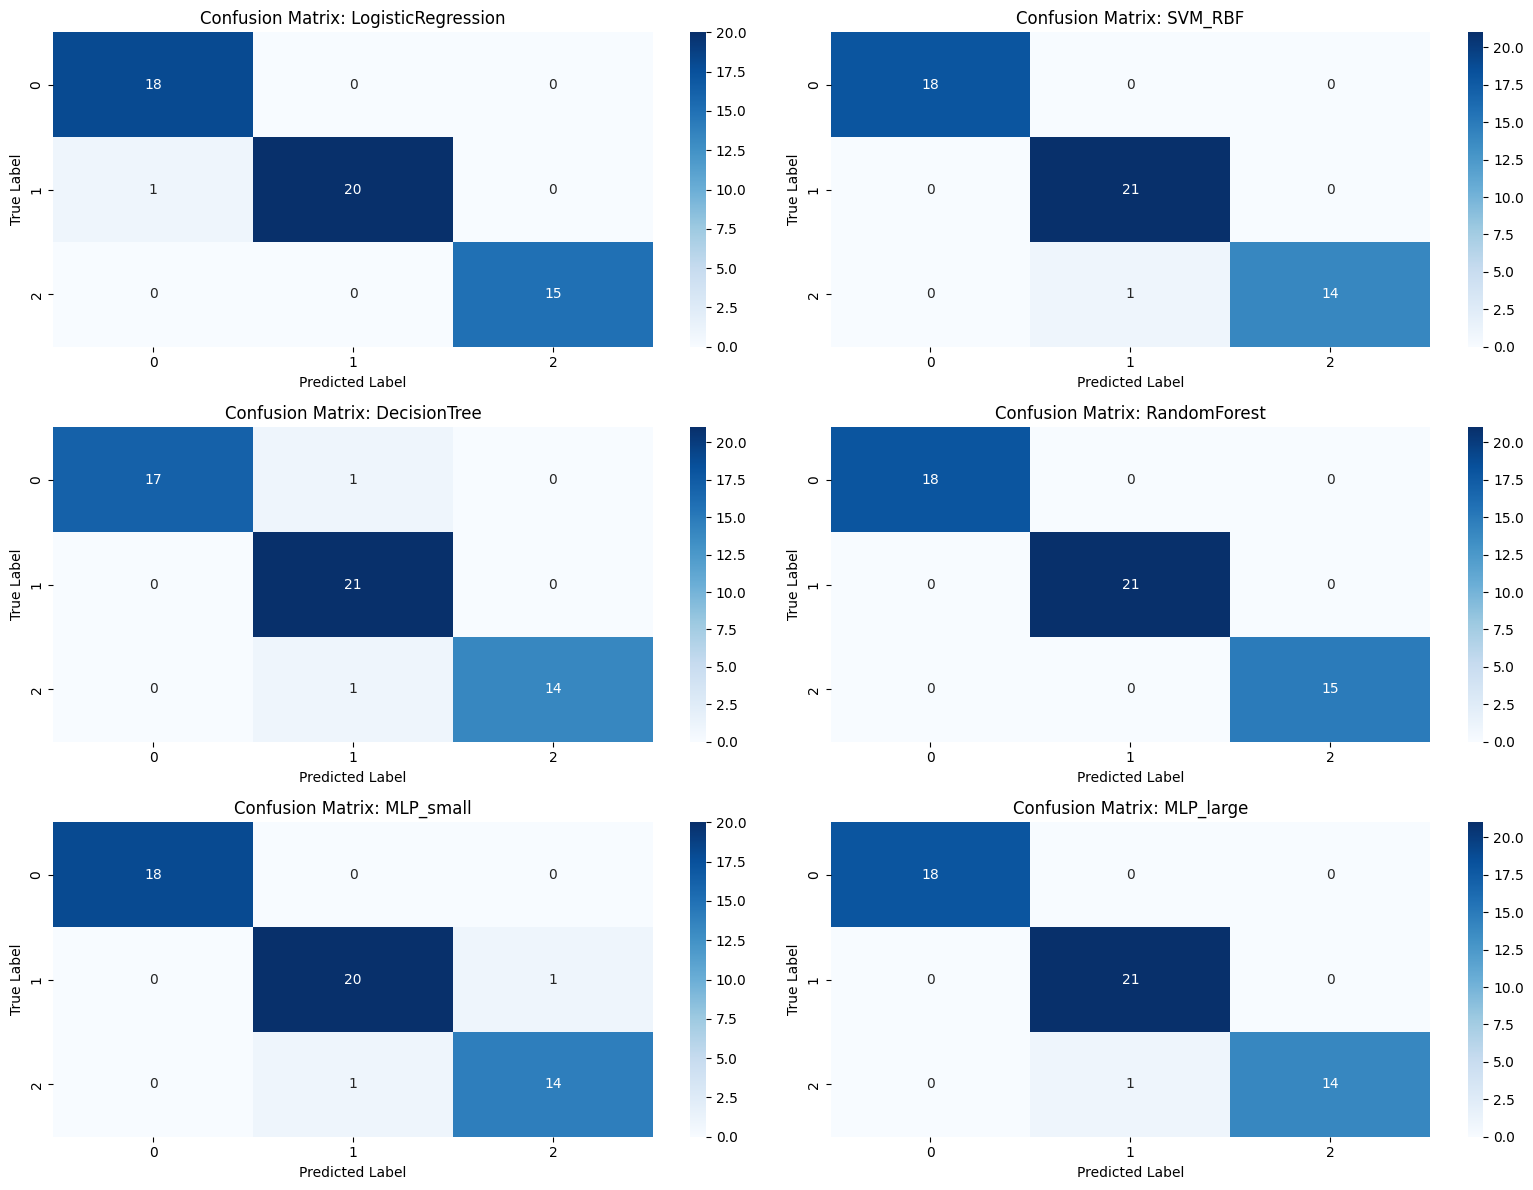

In [ ]:
# Confusion matrices for each classifier are plotted in a 3x2 grid for visual comparison.
# This allows inspection of class-wise prediction behavior across models.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

for i, (name, cm) in enumerate(conf_matrices.items(), start=1):
    plt.subplot(3, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()


In [ ]:
# SUMMARY— Wine Dataset Classification

#In Part B, the Wine dataset was used to evaluate six different classification models: Logistic Regression, SVM with RBF kernel, Decision Tree, Random Forest, and two feed-forward neural networks of different sizes.
# The dataset contains 178 samples belonging to three wine cultivars and includes thirteen numerical features.
# The dataset was divided into 70% training and 30% testing data, ensuring all results were evaluated on unseen samples.

#Feature scaling was applied using StandardScaler for models that are sensitive to feature magnitude (Logistic Regression, SVM, and the two neural networks).
#Tree-based models were evaluated without scaling because their performance is unaffected by feature scale.
#All models were trained with suitable hyperparameters and evaluated using accuracy, macro-averaged F1-score, and confusion matrices.

# The comparison showed that some models were able to capture class boundaries more effectively than others.
#Typically, the SVM and the larger neural network achieved strong performance due to their ability to model nonlinear decision boundaries.
# Tree-based models such as Random Forest also performed well because of their ensemble nature.
#Simpler models like Logistic Regression tended to perform moderately, reflecting the dataset’s inherent nonlinearity.
#Confusion matrices further highlighted which classes were more difficult for each model to distinguish.

# Overall, this experiment demonstrated the importance of model selection and proper preprocessing.
# Models with nonlinear capacity generally performed better on this dataset, while regularization and scaling played key roles in stabilizing training for linear and neural models.
